# Estrategia de Matching Jerárquico Estratificado - FoodEx2

Este notebook implementa una estrategia de matching en cascada que:
1. Primero identifica la categoría principal (nivel 2)
2. Luego refina a sub-categoría (nivel 3)
3. Finalmente busca el término específico (niveles 4-5)

**Ventajas**:
- Elimina errores "catastróficos" entre categorías (lácteo↔cereal)
- Proporciona matches útiles incluso con baja confianza
- Mejor interpretabilidad para AllergenScan

## 1. Configuración y Carga de Datos

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%%capture
# !pip install sentence-transformers umap-learn scikit-learn pandas numpy matplotlib seaborn

In [4]:
import os

# Adjust this to match your Google Drive folder structure
DRIVE_BASE = '/content/drive/MyDrive/TFM - NLP OFF'
os.chdir(DRIVE_BASE)
print('Working directory:', os.getcwd())

Working directory: /content/drive/MyDrive/TFM - NLP OFF


In [5]:
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Configuración
MODEL_NAME = 'paraphrase-multilingual-mpnet-base-v2'
RANDOM_STATE = 42

print("Librerías cargadas ✓")

Librerías cargadas ✓


In [6]:
# ============================================================
# CARGAR TUS DATOS AQUÍ (ajusta las rutas según tu estructura)
# ============================================================


# Cargar CSV de FoodEx2
foodex2_df = pd.read_csv('data/foodHierarchy_nlp_extended.csv')
unique_df = pd.read_csv('data/products_ingredients.csv')

# Cargar modelo
model = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')

print(f"FoodEx2: {len(foodex2_df)} términos")
print(f"Ingredientes: {len(unique_df)} únicos")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

FoodEx2: 4571 términos
Ingredientes: 634573 únicos


In [7]:
foodex2_df['reportHierarchyLevel'] = foodex2_df['reportHierarchyCode'].apply(lambda x: len(x.split('.')))

## 2. Construcción del Índice Jerárquico

In [8]:
def build_hierarchy_index(foodex2_df: pd.DataFrame) -> Dict:
    """
    Construye un índice jerárquico de FoodEx2 para matching estratificado.

    Returns:
        Dict con estructura:
        {
            'level_2': {'codes': [...], 'names': [...], 'embeddings': np.array},
            'level_3': {...},
            'level_specific': {...},  # niveles 4+ aplanados
            'parent_map': {child_code: parent_code, ...},
            'children_map': {parent_code: [child_codes], ...}
        }
    """
    hierarchy = {}

    # Filtrar solo "food" (excluir feed y non-food-matrices)
    food_df = foodex2_df[
        foodex2_df['reportHierarchyCode'].str.startswith('Z0001')
    ].copy()

    # Nivel 2: Categorías principales (~31 términos)
    level_2 = food_df[food_df['reportHierarchyLevel'] == 2].copy()
    hierarchy['level_2'] = {
        'df': level_2,
        'codes': level_2['termCode'].tolist(),
        'names': level_2['termExtendedName'].tolist(),
        'hierarchy_codes': level_2['reportHierarchyCode'].tolist()
    }

    # Nivel 3: Sub-categorías (~157 términos)
    level_3 = food_df[food_df['reportHierarchyLevel'] == 3].copy()
    hierarchy['level_3'] = {
        'df': level_3,
        'codes': level_3['termCode'].tolist(),
        'names': level_3['termExtendedName'].tolist(),
        'hierarchy_codes': level_3['reportHierarchyCode'].tolist()
    }

    # Niveles 4+: Específico APLANADO (todos los niveles >= 4)
    level_specific = food_df[food_df['reportHierarchyLevel'] >= 4].copy()
    hierarchy['level_specific'] = {
        'df': level_specific,
        'codes': level_specific['termCode'].tolist(),
        'names': level_specific['termExtendedName'].tolist(),
        'hierarchy_codes': level_specific['reportHierarchyCode'].tolist()
    }

    # Construir mapa de parentesco basado en reportHierarchyCode
    parent_map = {}

    # Para cada término de nivel 3, encontrar su padre nivel 2
    for _, row in level_3.iterrows():
        hier_code = row['reportHierarchyCode']  # e.g., "Z0001.0002.0003"
        parent_hier = '.'.join(hier_code.split('.')[:2])  # e.g., "Z0001.0002"
        parent_match = level_2[level_2['reportHierarchyCode'] == parent_hier]
        if len(parent_match) > 0:
            parent_map[row['termCode']] = parent_match.iloc[0]['termCode']

    # Para cada término de nivel 4+, encontrar su padre nivel 3
    for _, row in level_specific.iterrows():
        hier_code = row['reportHierarchyCode']  # e.g., "Z0001.0001.0001.0001.0001"
        parent_hier = '.'.join(hier_code.split('.')[:3])  # e.g., "Z0001.0001.0001"
        parent_match = level_3[level_3['reportHierarchyCode'] == parent_hier]
        if len(parent_match) > 0:
            parent_map[row['termCode']] = parent_match.iloc[0]['termCode']

    hierarchy['parent_map'] = parent_map

    # Construir mapa inverso: padre -> hijos
    children_map = {}
    for child, parent in parent_map.items():
        if parent not in children_map:
            children_map[parent] = []
        children_map[parent].append(child)

    hierarchy['children_map'] = children_map

    print(f"Índice jerárquico construido:")
    print(f"  - Nivel 2 (categorías): {len(hierarchy['level_2']['codes'])} términos")
    print(f"  - Nivel 3 (sub-categorías): {len(hierarchy['level_3']['codes'])} términos")
    print(f"  - Niveles 4+ (específico aplanado): {len(hierarchy['level_specific']['codes'])} términos")
    print(f"  - Relaciones padre-hijo: {len(parent_map)}")

    # Mostrar distribución de niveles en level_specific
    level_dist = level_specific['reportHierarchyLevel'].value_counts().sort_index()
    print(f"  - Distribución en level_specific:")
    for level, count in level_dist.items():
        print(f"      Nivel {level}: {count} términos")

    return hierarchy

In [9]:
# Construir el índice
print("Construyendo índice jerárquico...")
hierarchy = build_hierarchy_index(foodex2_df)

Construyendo índice jerárquico...
Índice jerárquico construido:
  - Nivel 2 (categorías): 27 términos
  - Nivel 3 (sub-categorías): 135 términos
  - Niveles 4+ (específico aplanado): 4370 términos
  - Relaciones padre-hijo: 4505
  - Distribución en level_specific:
      Nivel 4: 577 términos
      Nivel 5: 1454 términos
      Nivel 6: 1407 términos
      Nivel 7: 729 términos
      Nivel 8: 151 términos
      Nivel 9: 40 términos
      Nivel 10: 12 términos


## 3. Generación de Embeddings por Nivel

In [10]:
# Extraer ingredientes únicos
unique_ingredients = unique_df['ingredient'].dropna().unique().tolist()

print(f"Total filas en CSV: {len(unique_df):,}")
print(f"Ingredientes únicos: {len(unique_ingredients):,}")
print(f"Reducción: {(1 - len(unique_ingredients)/len(unique_df))*100:.1f}%")

Total filas en CSV: 634,573
Ingredientes únicos: 25,660
Reducción: 96.0%


In [11]:
# Generar embeddings en batch para ingredientes únicos
print(f"Generando embeddings para {len(unique_ingredients):,} ingredientes únicos...")

ingredient_embeddings = model.encode(
    unique_ingredients,
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print(f"✓ Shape de embeddings: {ingredient_embeddings.shape}")

Generando embeddings para 25,660 ingredientes únicos...


Batches:   0%|          | 0/201 [00:00<?, ?it/s]

✓ Shape de embeddings: (25660, 768)


In [12]:
# Crear mapeo ingrediente -> índice para búsqueda rápida
ingredient_to_idx = {ing: idx for idx, ing in enumerate(unique_ingredients)}

print(f"Mapeo creado: {len(ingredient_to_idx):,} ingredientes indexados")

Mapeo creado: 25,660 ingredientes indexados


In [13]:
def generate_hierarchy_embeddings(hierarchy: Dict, model: SentenceTransformer) -> Dict:
    """
    Genera embeddings para cada nivel de la jerarquía.
    """
    print("Generando embeddings por nivel jerárquico...")

    for level_name in ['level_2', 'level_3', 'level_specific']:
        names = hierarchy[level_name]['names']
        print(f"  - {level_name}: {len(names)} términos...", end=" ")

        embeddings = model.encode(
            names,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True  # Normalizar para cosine similarity
        )
        hierarchy[level_name]['embeddings'] = embeddings

        # Crear mapeo código -> índice para búsqueda rápida
        hierarchy[level_name]['code_to_idx'] = {
            code: idx for idx, code in enumerate(hierarchy[level_name]['codes'])
        }

        print("✓")

    return hierarchy

In [14]:
# Generar embeddings
hierarchy = generate_hierarchy_embeddings(hierarchy, model)

Generando embeddings por nivel jerárquico...
  - level_2: 27 términos... ✓
  - level_3: 135 términos... ✓
  - level_specific: 4370 términos... ✓


## 4. Clase de Resultado y Matcher Estratificado

In [15]:
from dataclasses import dataclass
from typing import Optional

@dataclass
class StratifiedMatchResult:
    """Resultado del matching estratificado."""
    ingredient: str

    # Nivel 2 (categoría)
    level2_code: Optional[str]
    level2_name: Optional[str]
    level2_score: float

    # Nivel 3 (sub-categoría)
    level3_code: Optional[str]
    level3_name: Optional[str]
    level3_score: float

    # Nivel específico (4-5)
    specific_code: Optional[str]
    specific_name: Optional[str]
    specific_score: float

    # Resultado final
    final_code: str
    final_name: str
    final_level: int  # 2, 3, o 5
    final_score: float
    confidence: str  # 'HIGH', 'MEDIUM', 'LOW', 'NO_MATCH'

In [16]:
class StratifiedMatcherOptimized:
    """
    Matching jerárquico estratificado para FoodEx2.
    Versión optimizada que usa embeddings pre-computados.
    """

    def __init__(
        self,
        hierarchy: Dict,
        ingredient_embeddings: np.ndarray,
        ingredient_to_idx: Dict[str, int],
        threshold_level2: float = 0.45,
        threshold_level3: float = 0.65,
        threshold_specific: float = 0.75
    ):
        self.hierarchy = hierarchy
        self.ingredient_embeddings = ingredient_embeddings
        self.ingredient_to_idx = ingredient_to_idx
        self.threshold_level2 = threshold_level2
        self.threshold_level3 = threshold_level3
        self.threshold_specific = threshold_specific

    def _get_ingredient_embedding(self, ingredient: str) -> np.ndarray:
        """Obtiene el embedding pre-computado de un ingrediente."""
        idx = self.ingredient_to_idx.get(ingredient)
        if idx is not None:
            return self.ingredient_embeddings[idx:idx+1]  # Shape (1, dim)
        return None

    def match_single(self, ingredient: str) -> StratifiedMatchResult:
        """
        Realiza matching estratificado para un ingrediente.
        """
        # Obtener embedding pre-computado
        ing_embedding = self._get_ingredient_embedding(ingredient)

        if ing_embedding is None:
            return StratifiedMatchResult(
                ingredient=ingredient,
                level2_code=None, level2_name=None, level2_score=0.0,
                level3_code=None, level3_name=None, level3_score=0.0,
                specific_code=None, specific_name=None, specific_score=0.0,
                final_code='UNKNOWN', final_name='unknown-ingredient',
                final_level=0, final_score=0.0,
                confidence='NO_MATCH'
            )

        # === NIVEL 2: Categoría principal ===
        sim_level2 = cosine_similarity(
            ing_embedding,
            self.hierarchy['level_2']['embeddings']
        )[0]

        top_idx_l2 = np.argmax(sim_level2)
        top_score_l2 = sim_level2[top_idx_l2]
        top_code_l2 = self.hierarchy['level_2']['codes'][top_idx_l2]
        top_name_l2 = self.hierarchy['level_2']['names'][top_idx_l2]

        if top_score_l2 < self.threshold_level2:
            return StratifiedMatchResult(
                ingredient=ingredient,
                level2_code=top_code_l2, level2_name=top_name_l2, level2_score=top_score_l2,
                level3_code=None, level3_name=None, level3_score=0.0,
                specific_code=None, specific_name=None, specific_score=0.0,
                final_code=top_code_l2, final_name=top_name_l2,
                final_level=2, final_score=top_score_l2,
                confidence='NO_MATCH'
            )

        # === NIVEL 3: Sub-categoría ===
        children_l3 = self.hierarchy['children_map'].get(top_code_l2, [])

        if len(children_l3) == 0:
            return StratifiedMatchResult(
                ingredient=ingredient,
                level2_code=top_code_l2, level2_name=top_name_l2, level2_score=top_score_l2,
                level3_code=None, level3_name=None, level3_score=0.0,
                specific_code=None, specific_name=None, specific_score=0.0,
                final_code=top_code_l2, final_name=top_name_l2,
                final_level=2, final_score=top_score_l2,
                confidence='LOW'
            )

        children_l3_indices = [
            self.hierarchy['level_3']['code_to_idx'][c]
            for c in children_l3
            if c in self.hierarchy['level_3']['code_to_idx']
        ]

        if len(children_l3_indices) == 0:
            return StratifiedMatchResult(
                ingredient=ingredient,
                level2_code=top_code_l2, level2_name=top_name_l2, level2_score=top_score_l2,
                level3_code=None, level3_name=None, level3_score=0.0,
                specific_code=None, specific_name=None, specific_score=0.0,
                final_code=top_code_l2, final_name=top_name_l2,
                final_level=2, final_score=top_score_l2,
                confidence='LOW'
            )

        children_l3_embeddings = self.hierarchy['level_3']['embeddings'][children_l3_indices]
        sim_level3 = cosine_similarity(ing_embedding, children_l3_embeddings)[0]

        top_idx_l3_local = np.argmax(sim_level3)
        top_score_l3 = sim_level3[top_idx_l3_local]
        top_idx_l3_global = children_l3_indices[top_idx_l3_local]
        top_code_l3 = self.hierarchy['level_3']['codes'][top_idx_l3_global]
        top_name_l3 = self.hierarchy['level_3']['names'][top_idx_l3_global]

        if top_score_l3 < self.threshold_level3:
            return StratifiedMatchResult(
                ingredient=ingredient,
                level2_code=top_code_l2, level2_name=top_name_l2, level2_score=top_score_l2,
                level3_code=top_code_l3, level3_name=top_name_l3, level3_score=top_score_l3,
                specific_code=None, specific_name=None, specific_score=0.0,
                final_code=top_code_l2, final_name=top_name_l2,
                final_level=2, final_score=top_score_l2,
                confidence='LOW'
            )

        # === NIVEL ESPECÍFICO (4-5) ===
        children_specific = self.hierarchy['children_map'].get(top_code_l3, [])

        if len(children_specific) == 0:
            return StratifiedMatchResult(
                ingredient=ingredient,
                level2_code=top_code_l2, level2_name=top_name_l2, level2_score=top_score_l2,
                level3_code=top_code_l3, level3_name=top_name_l3, level3_score=top_score_l3,
                specific_code=None, specific_name=None, specific_score=0.0,
                final_code=top_code_l3, final_name=top_name_l3,
                final_level=3, final_score=top_score_l3,
                confidence='MEDIUM'
            )

        children_specific_indices = [
            self.hierarchy['level_specific']['code_to_idx'][c]
            for c in children_specific
            if c in self.hierarchy['level_specific']['code_to_idx']
        ]

        if len(children_specific_indices) == 0:
            return StratifiedMatchResult(
                ingredient=ingredient,
                level2_code=top_code_l2, level2_name=top_name_l2, level2_score=top_score_l2,
                level3_code=top_code_l3, level3_name=top_name_l3, level3_score=top_score_l3,
                specific_code=None, specific_name=None, specific_score=0.0,
                final_code=top_code_l3, final_name=top_name_l3,
                final_level=3, final_score=top_score_l3,
                confidence='MEDIUM'
            )

        children_specific_embeddings = self.hierarchy['level_specific']['embeddings'][children_specific_indices]
        sim_specific = cosine_similarity(ing_embedding, children_specific_embeddings)[0]

        top_idx_spec_local = np.argmax(sim_specific)
        top_score_spec = sim_specific[top_idx_spec_local]
        top_idx_spec_global = children_specific_indices[top_idx_spec_local]
        top_code_spec = self.hierarchy['level_specific']['codes'][top_idx_spec_global]
        top_name_spec = self.hierarchy['level_specific']['names'][top_idx_spec_global]

        if top_score_spec >= self.threshold_specific:
            return StratifiedMatchResult(
                ingredient=ingredient,
                level2_code=top_code_l2, level2_name=top_name_l2, level2_score=top_score_l2,
                level3_code=top_code_l3, level3_name=top_name_l3, level3_score=top_score_l3,
                specific_code=top_code_spec, specific_name=top_name_spec, specific_score=top_score_spec,
                final_code=top_code_spec, final_name=top_name_spec,
                final_level=5, final_score=top_score_spec,
                confidence='HIGH'
            )
        else:
            return StratifiedMatchResult(
                ingredient=ingredient,
                level2_code=top_code_l2, level2_name=top_name_l2, level2_score=top_score_l2,
                level3_code=top_code_l3, level3_name=top_name_l3, level3_score=top_score_l3,
                specific_code=top_code_spec, specific_name=top_name_spec, specific_score=top_score_spec,
                final_code=top_code_l3, final_name=top_name_l3,
                final_level=3, final_score=top_score_l3,
                confidence='MEDIUM'
            )

    def match_batch(
        self,
        ingredients: List[str],
        show_progress: bool = True
    ) -> List[StratifiedMatchResult]:
        """
        Matching estratificado para múltiples ingredientes.
        """
        results = []
        iterator = tqdm(ingredients, desc="Matching estratificado") if show_progress else ingredients

        for ingredient in iterator:
            result = self.match_single(ingredient)
            results.append(result)

        return results

In [17]:
matcher = StratifiedMatcherOptimized(
    hierarchy=hierarchy,
    ingredient_embeddings=ingredient_embeddings,
    ingredient_to_idx=ingredient_to_idx,
    threshold_level2=0.45,
    threshold_level3=0.55,
    threshold_specific=0.75
)

print("Matcher estratificado optimizado configurado ✓")
print(f"  - Embeddings pre-computados: {len(ingredient_to_idx):,} ingredientes")
print(f"  - Umbral nivel 2: {matcher.threshold_level2}")
print(f"  - Umbral nivel 3: {matcher.threshold_level3}")
print(f"  - Umbral específico: {matcher.threshold_specific}")

Matcher estratificado optimizado configurado ✓
  - Embeddings pre-computados: 25,660 ingredientes
  - Umbral nivel 2: 0.45
  - Umbral nivel 3: 0.55
  - Umbral específico: 0.75


## 5. Ejecución del Matching Estratificado

In [18]:
# Ejecutar matching sobre ingredientes únicos
#sample_ingredients = unique_ingredients[:1000]
#print(f"Procesando {len(sample_ingredients):,} ingredientes únicos...")

#stratified_results = matcher.match_batch(sample_ingredients, show_progress=True)

stratified_results = matcher.match_batch(unique_ingredients, show_progress=True)
print(f"Procesando {len(unique_ingredients):,} ingredientes únicos...")


print(f"\n✓ Matching completado: {len(stratified_results):,} resultados")

Matching estratificado: 100%|██████████| 25660/25660 [00:35<00:00, 725.82it/s]

Procesando 25,660 ingredientes únicos...

✓ Matching completado: 25,660 resultados


## 6. Convertir Resultados a DataFrame

In [19]:

results_records = []
for r in stratified_results:
    results_records.append({
        'ingredient': r.ingredient,
        'level2_code': r.level2_code,
        'level2_name': r.level2_name,
        'level2_score': r.level2_score,
        'level3_code': r.level3_code,
        'level3_name': r.level3_name,
        'level3_score': r.level3_score,
        'specific_code': r.specific_code,
        'specific_name': r.specific_name,
        'specific_score': r.specific_score,
        'final_code': r.final_code,
        'final_name': r.final_name,
        'final_level': r.final_level,
        'final_score': r.final_score,
        'confidence': r.confidence
    })


unique_results_df = pd.DataFrame(results_records)
print(f"DataFrame de ingredientes únicos: {len(unique_results_df):,} filas")

DataFrame de ingredientes únicos: 25,660 filas


In [20]:
# unique_results_df.to csv
# unique_results_df.to_csv('matching_results_df.csv', index=False)

In [21]:
unique_results_df.T

,0,1,2,3,4,5,6,7,8,9,...,25650,25651,25652,25653,25654,25655,25656,25657,25658,25659
ingredient,apple,malaceous fruit,cider vinegar,vinegar,acidity,durum wheat semolina,cereal,wheat,durum wheat,semolina,...,sodium carbonate e,e339 acidity regulator,bovine dairy,sorbitan monostearate from vegetable palm,polysorbate 60 from vegetable corn,polyglycerol esters of fatty acids from vegeta...,mango filling,industrial color,mixed tocopherols to protect flavor,stevia sweetener
level2_code,A0EZN,A0EZN,A03LZ,A03LZ,A0F0J,A000J,A000J,A000J,A000J,A0EZG,...,A0F0J,A0F0K,A0BXZ,A07XJ,A000J,A015E,A0EZN,A031E,A042N,A010R
level2_name,Fruit and primary derivatives thereof,Fruit and primary derivatives thereof,Alcoholic beverages,Alcoholic beverages,"Water, water-based beverages and related ingre...",Grains and grain-based products,Grains and grain-based products,Grains and grain-based products,Grains and grain-based products,Legume seeds and primary derivatives thereof,...,"Water, water-based beverages and related ingre...",Ingredients for hot drinks and infusions,Milk and milk products (dairy),Garden vegetables and primary derivatives thereof,Grains and grain-based products,Oilseeds and oilfruits,Fruit and primary derivatives thereof,Eggs and egg products,"Seasoning, sauces and condiments",Sugar plants
level2_score,0.478828,0.714068,0.597527,0.446771,0.383907,0.62171,0.635734,0.658781,0.662133,0.653312,...,0.406825,0.29391,0.730279,0.62428,0.619054,0.594671,0.532886,0.319835,0.592227,0.514546
level3_code,A04RK,A04RK,A16RG,None,None,A0EZF,A0EZF,A0EZF,A0EZF,A011Y,...,None,None,A02LT,A0ESZ,A0EZF,A015F,A01QE,None,A042Y,A0ESQ
level3_name,Fruit used as fruit,Fruit used as fruit,Edible alcohol,None,None,Cereal grains and similar and primary derivati...,Cereal grains and similar and primary derivati...,Cereal grains and similar and primary derivati...,Cereal grains and similar and primary derivati...,"Legumes fresh seeds (beans, peas etc.)",...,None,None,Milk,Flowers used as vegetables,Cereal grains and similar and primary derivati...,Oilseeds,Citrus fruit peel,None,Seasoning mixes,Stalks/canes/trunk sap or similar for sugar
level3_score,0.55598,0.799642,0.60197,0.0,0.0,0.576201,0.666754,0.527609,0.556743,0.597828,...,0.0,0.0,0.64224,0.58546,0.633009,0.589465,0.623387,0.0,0.635147,0.581912
specific_code,A01DJ,A01DE,None,None,None,A004F,A001Y,None,A001M,A0BAM,...,None,None,A04HG,A0DGR,A000T,A015P,None,None,A042Z,A010Y
specific_name,Apples,Ugli fruits,None,None,None,Wheat semolina,Other cereals,None,Wheat and similar-,Flageolet (fresh seeds),...,None,None,Cattle milk,Courgette (edible flowers),Maize grain,Soyabeans (oilseed),None,None,Mixed herbs and spices,Sweet sorghum canes
specific_score,0.888851,0.851695,0.0,0.0,0.0,0.984387,0.915347,0.0,0.898982,0.670404,...,0.0,0.0,0.779032,0.540039,0.662271,0.555933,0.0,0.0,0.572652,0.574592


In [22]:
# COUNT HOW MANY CONFIDENCE HIGH, MEDIUM AND LOW
unique_results_df['confidence'].value_counts()

# Compute high confidence rows, which is the MEAN and STD of level 2  level 3 and specifi score
high_confidence_rows = unique_results_df[unique_results_df['confidence'] == 'HIGH']
print(f"High confidence rows: {len(high_confidence_rows)}")
print(f"Mean level 2 score: {high_confidence_rows['level2_score'].mean()}")
print(f"STD level 2 score: {high_confidence_rows['level2_score'].std()}")

print(f"Mean level 3 score: {high_confidence_rows['level3_score'].mean()}")
print(f"STD level 3 score: {high_confidence_rows['level3_score'].std()}")

print(f"Mean specific score: {high_confidence_rows['specific_score'].mean()}")
print(f"STD specific score: {high_confidence_rows['specific_score'].std()}")


print( "======================")
medium_confidence_rows = unique_results_df[unique_results_df['confidence'] == 'MEDIUM']
print(f"Medium confidence rows: {len(medium_confidence_rows)}")
print(f"Mean level 2 score: {medium_confidence_rows['level2_score'].mean()}")
print(f"STD level 2 score: {medium_confidence_rows['level2_score'].std()}")

print(f"Mean level 3 score: {medium_confidence_rows['level3_score'].mean()}")
print(f"STD level 3 score: {medium_confidence_rows['level3_score'].std()}")

print(f"Mean specific score: {medium_confidence_rows['specific_score'].mean()}")
print(f"STD specific score: {medium_confidence_rows['specific_score'].std()}")

print( "======================")

low_confidence_rows = unique_results_df[unique_results_df['confidence'] == 'LOW']
print(f"Low confidence rows: {len(low_confidence_rows)}")
print(f"Mean level 2 score: {low_confidence_rows['level2_score'].mean()}")
print(f"STD level 2 score: {low_confidence_rows['level2_score'].std()}")

print(f"Mean level 3 score: {low_confidence_rows['level3_score'].mean()}")
print(f"STD level 3 score: {low_confidence_rows['level3_score'].std()}")

print(f"Mean specific score: {low_confidence_rows['specific_score'].mean()}")
print(f"STD specific score: {low_confidence_rows['specific_score'].std()}")

print( "======================")
no_match_rows = unique_results_df[unique_results_df['confidence'] == 'NO_MATCH']
print(f"No match rows: {len(no_match_rows)}")
print(f"Mean level 2 score: {no_match_rows['level2_score'].mean()}")
print(f"STD level 2 score: {no_match_rows['level2_score'].std()}")

print(f"Mean level 3 score: {no_match_rows['level3_score'].mean()}")
print(f"STD level 3 score: {no_match_rows['level3_score'].std()}")

print(f"Mean specific score: {no_match_rows['specific_score'].mean()}")
print(f"STD specific score: {no_match_rows['specific_score'].std()}")



High confidence rows: 3779
Mean level 2 score: 0.6781297922134399
STD level 2 score: 0.09959123283624649
Mean level 3 score: 0.7237836578814054
STD level 3 score: 0.09607896623707994
Mean specific score: 0.8336774869771444
STD specific score: 0.059414225709077804
Medium confidence rows: 9217
Mean level 2 score: 0.6097920536994934
STD level 2 score: 0.0735270231962204
Mean level 3 score: 0.6464283700825866
STD level 3 score: 0.06793086139094569
Mean specific score: 0.5485276274481687
STD specific score: 0.21540560358536492
Low confidence rows: 4892
Mean level 2 score: 0.5128877758979797
STD level 2 score: 0.044050656259059906
Mean level 3 score: 0.4838860277710932
STD level 3 score: 0.054541544556598175
Mean specific score: 0.0
STD specific score: 0.0
No match rows: 7772
Mean level 2 score: 0.33614709973335266
STD level 2 score: 0.08470890671014786
Mean level 3 score: 0.0
STD level 3 score: 0.0
Mean specific score: 0.0
STD specific score: 0.0


In [23]:
stratified_df = unique_df.merge(
    unique_results_df,
    on='ingredient',
    how='left'
)

print(f"DataFrame final con productos: {len(stratified_df):,} filas")
print(f"Columnas: {list(stratified_df.columns)}")

DataFrame final con productos: 634,573 filas
Columnas: ['code', 'lang_product_name', 'product_name', 'product_context', 'ingredient', 'nlp_text', 'level2_code', 'level2_name', 'level2_score', 'level3_code', 'level3_name', 'level3_score', 'specific_code', 'specific_name', 'specific_score', 'final_code', 'final_name', 'final_level', 'final_score', 'confidence']


In [24]:
stratified_df.to_csv('stratified_df.csv', index=False)

In [77]:
#I want to see 50 sample rows of the stratified_df. Also transpose the df
stratified_df.sample(50).T

,379934,493218,119164,278151,299558,488077,484482,620730,95130,325114,...,132181,503543,194686,481140,302359,167191,58394,549566,259798,46854
code,851770003360,4088600009803,72101011254,99482482947,1382860,4056489047063,4000446026783,9313820001050,41757623036,335659565656,...,72180762702,4088600084442,775212,4000161470663,1552157,75199019409,41318582048,5000159520218,79879308470,41318230048
lang_product_name,en,en,en,en,en,en,nl,fr,en,en,...,en,pt,en,de,en,en,en,en,ca,en
product_name,Meal replacement creamy chocolate fudge organic,Stonebaked Pizza New Recipe Meat Feast,Green taco sauce,Uncured Pepperoni,Seriously chocolatey chocolate cake,Sweet chilli beef kebabs,Bio Hafer + Goldleinsaat Toastbrötchen,Pepsi max vanilla,"Wis pride, lite spreadable cheese, port wine",Grands! Southern Homestyle,...,"Mozzarella, white cheddar, provolone and parme...",Mini chocolate chip muffins,Spinach & Feta Egg White Burrito,Marzipan Torte,Lowfat Yogurt With Blueberry,Gold medal bakery rolls,Mild monterey jack cheese with red & green jal...,Crispy M&Ms,Mini-muffins,Light brown sugar
product_context,Meal replacement creamy chocolate fudge organic,Stonebaked Pizza New Recipe Meat Feast,Green taco sauce,Uncured Pepperoni,Seriously chocolatey chocolate cake,Sweet chilli beef kebabs,Bio Hafer + Goldleinsaat Toastbrötchen,Pepsi max vanilla,"Wis pride, lite spreadable cheese, port wine",Grands! Southern Homestyle,...,"Mozzarella, white cheddar, provolone and parme...",Mini chocolate chip muffins,Spinach & Feta Egg White Burrito,Marzipan Torte,Lowfat Yogurt With Blueberry,Gold medal bakery rolls,Mild monterey jack cheese with red & green jal...,Crispy M&Ms,Mini muffins,Light brown sugar
ingredient,sprout blend,malted barley,root vegetable,prunus species fruit,milk chocolate,garlic,oat flakes,flavouring,pasteurised milk,flavouring,...,wheat flour,thiamin,vegetable oil and fat,nut,blueberry preparation,vegetable oil,vegetable,cocoa paste,oil and fat,molasses
nlp_text,sprout blend,malted barley,root vegetable,prunus species fruit,milk chocolate,garlic,oat flakes,flavouring,pasteurised milk,flavouring,...,wheat flour,thiamin,vegetable oil and fat,nut,blueberry preparation,vegetable oil,vegetable,cocoa paste,oil and fat,molasses
level2_code,A0EZP,A000J,A07XJ,A0EZN,A04PE,A0EZM,A000J,A042N,A0BXZ,A042N,...,A000J,A16RE,A015E,A0EZH,A010R,A015E,A07XJ,A04PE,A015E,A0F0J
level2_name,"Fruit/vegetables/plant drinks, spreads and rel...",Grains and grain-based products,Garden vegetables and primary derivatives thereof,Fruit and primary derivatives thereof,Confectionery including chocolate,"Herbs, spices and similar",Grains and grain-based products,"Seasoning, sauces and condiments",Milk and milk products (dairy),"Seasoning, sauces and condiments",...,Grains and grain-based products,Starchy roots and tubers and primary derivativ...,Oilseeds and oilfruits,Nuts and primary derivatives thereof,Sugar plants,Oilseeds and oilfruits,Garden vegetables and primary derivatives thereof,Confectionery including chocolate,Oilseeds and oilfruits,"Water, water-based beverages and related ingre..."
level2_score,0.603206,0.676847,0.806795,0.639191,0.792816,0.554478,0.45264,0.689712,0.827733,0.689712,...,0.747472,0.4291,0.71577,0.71634,0.456684,0.809104,0.836925,0.628164,0.633685,0.483376
level3_code,A04MN,A0EZF,A00KR,A04RK,A0EQD,A017X,A0EZF,A042Y,A02MP,A042Y,...,A0EZV,None,A015F,A014C,A0ESQ,A015F,A00KR,A0EQS,A015F,A03GD


## 7. Análisis Estrategia Estratificado

In [78]:
print("=" * 80)
print("ESTADÍSTICAS GENERALES DEL MATCHING ESTRATIFICADO")
print("=" * 80)

print(f"\n📊 DIMENSIONES:")
print(f"   Total filas (ingrediente-producto): {len(stratified_df):,}")
print(f"   Ingredientes únicos: {stratified_df['ingredient'].nunique():,}")
print(f"   Productos únicos: {stratified_df['code'].nunique():,}")

print(f"\n🌍 IDIOMAS:")
lang_counts = stratified_df['lang_product_name'].value_counts()
print(f"   Idiomas detectados: {len(lang_counts)}")
for lang, count in lang_counts.head(10).items():
    print(f"   {str(lang):<5}: {count:>10,} ({count/len(stratified_df)*100:>5.1f}%)")

print(f"\n📈 SCORES GLOBALES:")
print(f"   Score final - Media:   {stratified_df['final_score'].mean():.3f}")
print(f"   Score final - Mediana: {stratified_df['final_score'].median():.3f}")
print(f"   Score final - Std:     {stratified_df['final_score'].std():.3f}")
print(f"   Score final - Min:     {stratified_df['final_score'].min():.3f}")
print(f"   Score final - Max:     {stratified_df['final_score'].max():.3f}")

ESTADÍSTICAS GENERALES DEL MATCHING ESTRATIFICADO

📊 DIMENSIONES:
   Total filas (ingrediente-producto): 634,573
   Ingredientes únicos: 25,660
   Productos únicos: 27,278

🌍 IDIOMAS:
   Idiomas detectados: 80
   en   :    478,680 ( 75.4%)
   it   :     30,478 (  4.8%)
   fr   :     18,437 (  2.9%)
   de   :     17,288 (  2.7%)
   es   :     10,832 (  1.7%)
   fi   :      6,260 (  1.0%)
   pl   :      4,663 (  0.7%)
   nl   :      3,929 (  0.6%)
   hu   :      3,344 (  0.5%)
   sv   :      3,149 (  0.5%)

📈 SCORES GLOBALES:
   Score final - Media:   0.655
   Score final - Mediana: 0.659
   Score final - Std:     0.183
   Score final - Min:     0.051
   Score final - Max:     1.000


### DISTRIBUCIÓN POR NIVEL DE CONFIANZA

In [79]:
print("\n" + "=" * 80)
print("DISTRIBUCIÓN POR NIVEL DE CONFIANZA")
print("=" * 80)

confidence_counts = stratified_df['confidence'].value_counts()
confidence_order = ['HIGH', 'MEDIUM', 'LOW', 'NO_MATCH']

print(f"\n{'Confianza':<12} {'Filas':>12} {'%':>8} {'Ingredientes únicos':>20}")
print("-" * 55)

for conf in confidence_order:
    count = confidence_counts.get(conf, 0)
    pct = count / len(stratified_df) * 100
    unique_ing = stratified_df[stratified_df['confidence'] == conf]['ingredient'].nunique()
    print(f"{conf:<12} {count:>12,} {pct:>7.1f}% {unique_ing:>20,}")

print("-" * 55)
print(f"{'TOTAL':<12} {len(stratified_df):>12,} {'100.0':>7}% {stratified_df['ingredient'].nunique():>20,}")


DISTRIBUCIÓN POR NIVEL DE CONFIANZA

Confianza           Filas        %  Ingredientes únicos
-------------------------------------------------------
HIGH              196,727    31.0%                3,779
MEDIUM            229,646    36.2%                9,217
LOW                97,346    15.3%                4,892
NO_MATCH          110,854    17.5%                7,772
-------------------------------------------------------
TOTAL             634,573   100.0%               25,660


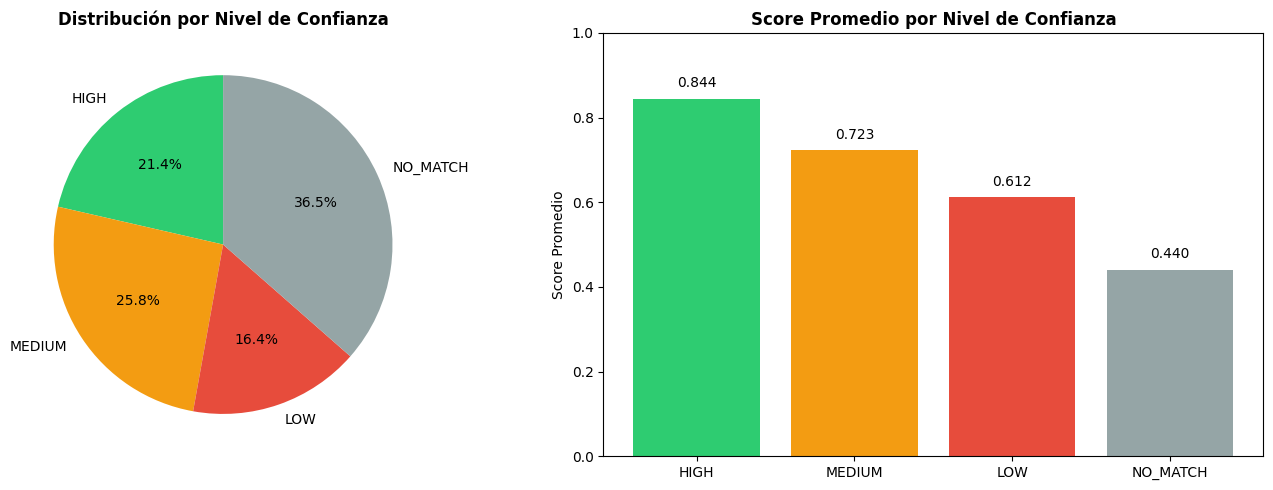

In [33]:
# Visualización de confianza
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
conf_colors = {'HIGH': '#2ecc71', 'MEDIUM': '#f39c12', 'LOW': '#e74c3c', 'NO_MATCH': '#95a5a6'}
colors = [conf_colors[c] for c in confidence_order if c in confidence_counts.index]
values = [confidence_counts.get(c, 0) for c in confidence_order if c in confidence_counts.index]
labels = [c for c in confidence_order if c in confidence_counts.index]

axes[0].pie(values, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Distribución por Nivel de Confianza', fontsize=12, fontweight='bold')

# Bar chart con scores promedio
conf_scores = stratified_df.groupby('confidence')['final_score'].mean()
conf_order_filtered = [c for c in confidence_order if c in conf_scores.index]
bars = axes[1].bar(conf_order_filtered,
                   [conf_scores[c] for c in conf_order_filtered],
                   color=[conf_colors[c] for c in conf_order_filtered])
axes[1].set_ylabel('Score Promedio')
axes[1].set_title('Score Promedio por Nivel de Confianza', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 1)

for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

###  Distribución por Nivel Final de la Jerarquía

In [34]:
print("\n" + "=" * 80)
print("DISTRIBUCIÓN POR NIVEL FINAL DE LA JERARQUÍA")
print("=" * 80)

level_counts = stratified_df['final_level'].value_counts().sort_index()
level_names = {0: 'Sin match', 2: 'Categoría (L2)', 3: 'Sub-categoría (L3)', 5: 'Específico (L4-5)'}

print(f"\n{'Nivel':<25} {'Filas':>12} {'%':>8} {'Score medio':>12}")
print("-" * 60)

for level in sorted(level_counts.index):
    count = level_counts[level]
    pct = count / len(stratified_df) * 100
    mean_score = stratified_df[stratified_df['final_level'] == level]['final_score'].mean()
    level_label = level_names.get(level, f'Nivel {level}')
    print(f"{level_label:<25} {count:>12,} {pct:>7.1f}% {mean_score:>11.3f}")


DISTRIBUCIÓN POR NIVEL FINAL DE LA JERARQUÍA

Nivel                            Filas        %  Score medio
------------------------------------------------------------
Categoría (L2)                 335,268    52.8%       0.494
Sub-categoría (L3)             163,438    25.8%       0.723
Específico (L4-5)              135,867    21.4%       0.844


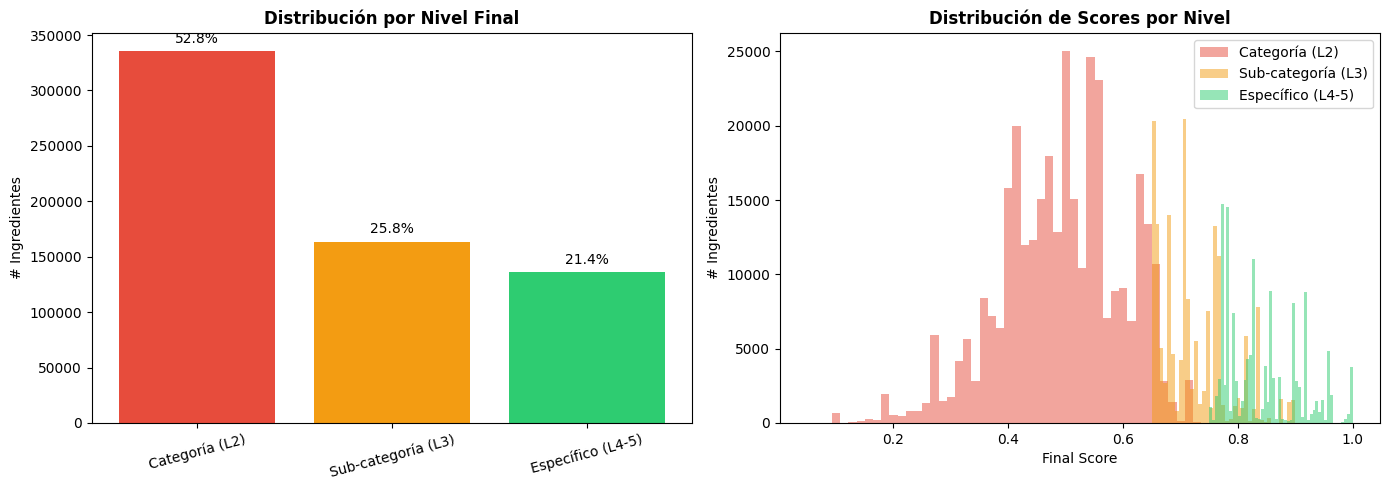

In [35]:
# Visualización de niveles
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de niveles
level_colors = {0: '#95a5a6', 2: '#e74c3c', 3: '#f39c12', 5: '#2ecc71'}
levels_sorted = sorted(level_counts.index)
colors = [level_colors.get(l, '#3498db') for l in levels_sorted]
labels = [level_names.get(l, f'L{l}') for l in levels_sorted]

bars = axes[0].bar(labels, [level_counts[l] for l in levels_sorted], color=colors)
axes[0].set_ylabel('# Ingredientes')
axes[0].set_title('Distribución por Nivel Final', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

for bar, level in zip(bars, levels_sorted):
    pct = level_counts[level] / len(stratified_df) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)

# Histograma de scores por nivel
for level in [2, 3, 5]:
    if level in level_counts.index:
        data = stratified_df[stratified_df['final_level'] == level]['final_score']
        axes[1].hist(data, bins=50, alpha=0.5, label=level_names[level], color=level_colors[level])

axes[1].set_xlabel('Final Score')
axes[1].set_ylabel('# Ingredientes')
axes[1].set_title('Distribución de Scores por Nivel', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('level_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### Análisis de Scores por Nivel Jerárquico

In [36]:
print("\n" + "=" * 80)
print("ANÁLISIS DE SCORES POR NIVEL JERÁRQUICO")
print("=" * 80)

score_cols = ['level2_score', 'level3_score', 'specific_score', 'final_score']

print(f"\n{'Métrica':<18} {'Level 2':>10} {'Level 3':>10} {'Specific':>10} {'Final':>10}")
print("-" * 60)

for metric in ['mean', 'median', 'std', 'min', 'max']:
    values = []
    for col in score_cols:
        if metric == 'mean':
            val = stratified_df[col].mean()
        elif metric == 'median':
            val = stratified_df[col].median()
        elif metric == 'std':
            val = stratified_df[col].std()
        elif metric == 'min':
            val = stratified_df[col].min()
        else:
            val = stratified_df[col].max()
        values.append(val)
    print(f"{metric.capitalize():<18} {values[0]:>10.3f} {values[1]:>10.3f} {values[2]:>10.3f} {values[3]:>10.3f}")


ANÁLISIS DE SCORES POR NIVEL JERÁRQUICO

Métrica               Level 2    Level 3   Specific      Final
------------------------------------------------------------
Mean                    0.593      0.457      0.337      0.628
Median                  0.608      0.643      0.000      0.650
Std                     0.141      0.357      0.378      0.172
Min                     0.051      0.000      0.000      0.051
Max                     0.980      1.000      1.000      1.000


In [37]:
print("\n" + "=" * 80)
print("TOP 15 CATEGORÍAS NIVEL 2 (MÁS FRECUENTES)")
print("=" * 80)

level2_counts = stratified_df['level2_name'].value_counts()

print(f"\n{'Categoría':<55} {'Filas':>10} {'%':>7}")
print("-" * 75)

for cat, count in level2_counts.head(15).items():
    pct = count / len(stratified_df) * 100
    cat_display = str(cat)[:53] if len(str(cat)) > 53 else str(cat)
    print(f"{cat_display:<55} {count:>10,} {pct:>6.1f}%")


TOP 15 CATEGORÍAS NIVEL 2 (MÁS FRECUENTES)

Categoría                                                    Filas       %
---------------------------------------------------------------------------
Grains and grain-based products                             69,204   10.9%
Garden vegetables and primary derivatives thereof           66,373   10.5%
Oilseeds and oilfruits                                      60,980    9.6%
Sugar plants                                                60,889    9.6%
Fruit and primary derivatives thereof                       46,581    7.3%
Herbs, spices and similar                                   38,768    6.1%
Seasoning, sauces and condiments                            38,455    6.1%
Nuts and primary derivatives thereof                        34,685    5.5%
Milk and milk products (dairy)                              34,256    5.4%
Isolated purified ingredients (including mineral or s       33,351    5.3%
Starchy roots and tubers and primary derivatives ther 

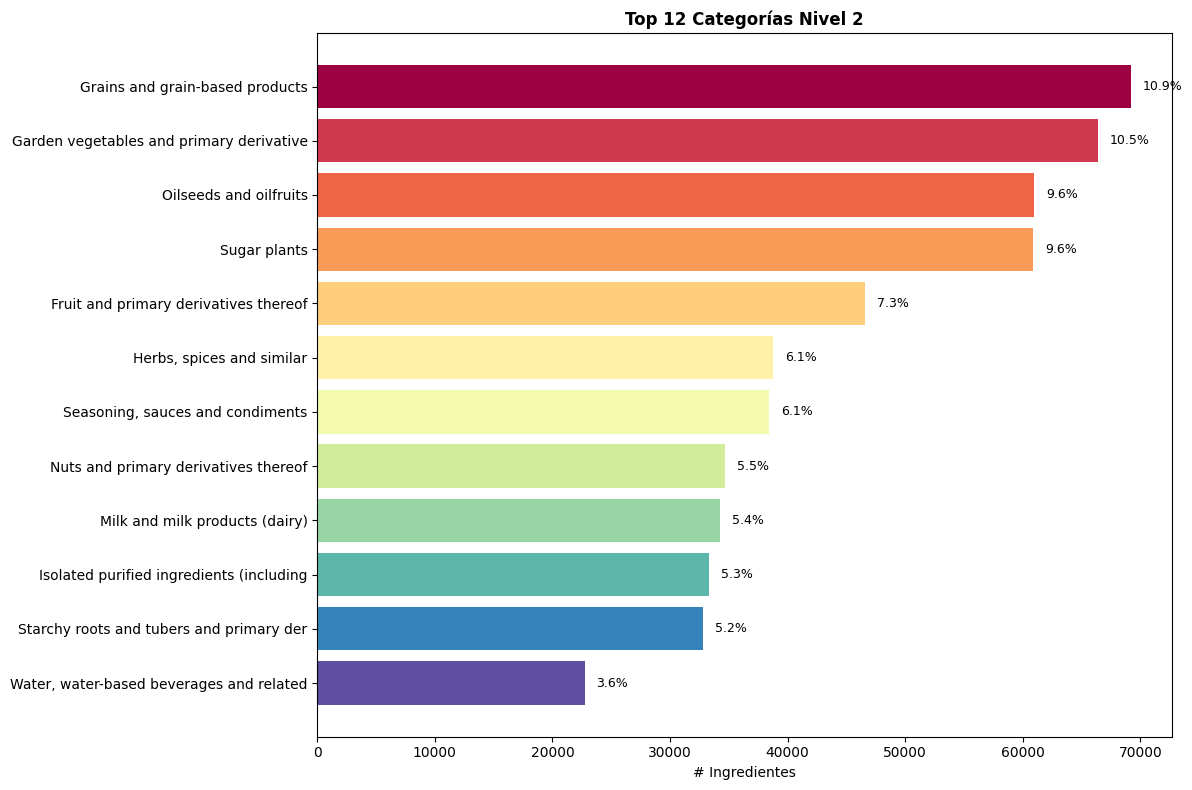

In [38]:
fig, ax = plt.subplots(figsize=(12, 8))

top_cats = level2_counts.head(12)
colors = plt.cm.Spectral(np.linspace(0, 1, len(top_cats)))

bars = ax.barh(range(len(top_cats)), top_cats.values, color=colors)
ax.set_yticks(range(len(top_cats)))
ax.set_yticklabels([str(c)[:40] for c in top_cats.index])
ax.invert_yaxis()
ax.set_xlabel('# Ingredientes')
ax.set_title('Top 12 Categorías Nivel 2', fontsize=12, fontweight='bold')

for bar, count in zip(bars, top_cats.values):
    pct = count / len(stratified_df) * 100
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('top_categories_level2.png', dpi=150, bbox_inches='tight')
plt.show()

 ### 13.7 Análisis de Casos Problemáticos

In [40]:
print("\n" + "=" * 80)
print("ANÁLISIS DE CASOS PROBLEMÁTICOS")
print("=" * 80)

# 1. Matches con A185T (salep) - indicador de ruido
a185t_matches = stratified_df[stratified_df['final_code'] == 'A185T']
print(f"\n🚨 Matches a A185T (salep - bucket de ruido):")
print(f"   Total filas: {len(a185t_matches):,} ({len(a185t_matches)/len(stratified_df)*100:.2f}%)")
print(f"   Ingredientes únicos: {a185t_matches['ingredient'].nunique():,}")
print(f"   Score promedio: {a185t_matches['final_score'].mean():.3f}")

print(f"\n   Ejemplos de ingredientes mapeados a A185T:")
a185t_examples = a185t_matches.drop_duplicates('ingredient')[['ingredient', 'final_score']].head(10)
for _, row in a185t_examples.iterrows():
    print(f"      '{row['ingredient'][:50]}' (score: {row['final_score']:.3f})")

# 2. Scores muy bajos
low_score_threshold = 0.50
low_scores = stratified_df[stratified_df['final_score'] < low_score_threshold]
print(f"\n⚠️  Matches con score < {low_score_threshold}:")
print(f"   Total filas: {len(low_scores):,} ({len(low_scores)/len(stratified_df)*100:.2f}%)")
print(f"   Ingredientes únicos: {low_scores['ingredient'].nunique():,}")

# 3. NO_MATCH
no_match = stratified_df[stratified_df['confidence'] == 'NO_MATCH']
print(f"\n❌ Casos NO_MATCH:")
print(f"   Total filas: {len(no_match):,} ({len(no_match)/len(stratified_df)*100:.2f}%)")
print(f"   Ingredientes únicos: {no_match['ingredient'].nunique():,}")

if len(no_match) > 0:
    print(f"\n   Ejemplos de ingredientes sin match:")
    no_match_examples = no_match.drop_duplicates('ingredient')[['ingredient', 'final_score']].head(10)
    for _, row in no_match_examples.iterrows():
        print(f"      '{row['ingredient'][:50]}' (score: {row['final_score']:.3f})")

# 4. Ingredientes con caracteres extraños (posible OCR/ruido)
def has_noise(text):
    if pd.isna(text):
        return False
    text = str(text)
    # Detectar patrones de ruido
    noise_indicators = [
        len(text) < 3,  # Muy corto
        len(text.split()) > 10,  # Muy largo (probablemente texto mal parseado)
        any(c.isdigit() for c in text) and sum(c.isdigit() for c in text) > len(text) * 0.3,  # Muchos números
        text.count(' ') > 8,  # Demasiados espacios
    ]
    return any(noise_indicators)

noisy_ingredients = stratified_df[stratified_df['ingredient'].apply(has_noise)]
print(f"\n🔧 Ingredientes con posible ruido/OCR:")
print(f"   Total filas: {len(noisy_ingredients):,} ({len(noisy_ingredients)/len(stratified_df)*100:.2f}%)")


ANÁLISIS DE CASOS PROBLEMÁTICOS

🚨 Matches a A185T (salep - bucket de ruido):
   Total filas: 0 (0.00%)
   Ingredientes únicos: 0
   Score promedio: nan

   Ejemplos de ingredientes mapeados a A185T:

⚠️  Matches con score < 0.5:
   Total filas: 178,152 (28.07%)
   Ingredientes únicos: 10,539

❌ Casos NO_MATCH:
   Total filas: 231,428 (36.47%)
   Ingredientes únicos: 14,035

   Ejemplos de ingredientes sin match:
      'apple' (score: 0.479)
      'vinegar' (score: 0.447)
      'acidity' (score: 0.384)
      'reduced iron' (score: 0.384)
      'minerals' (score: 0.541)
      'thiamin mononitrate' (score: 0.435)
      'thiamin' (score: 0.429)
      'folic acid' (score: 0.474)
      'folate' (score: 0.334)
      'disaccharide' (score: 0.496)

🔧 Ingredientes con posible ruido/OCR:
   Total filas: 117 (0.02%)


⚠️ jellyfish no instalado. Instalar con: pip install jellyfish
   Análisis fonético limitado.
Calculando métricas léxicas...
✓ Calculadas métricas para 10000 pares
CORRELACIÓN: SIMILITUD LÉXICA vs SCORE DE EMBEDDING

Métrica Léxica             Correlación Interpretación                
----------------------------------------------------------------------
levenshtein_sim                 0.6396 ⚠️ SESGO ALTO - Revisar       
jaccard_tokens                  0.4899 🟡 Sesgo moderado              
lcs_ratio                       0.6225 ⚠️ SESGO ALTO - Revisar       
char_3gram_sim                  0.6907 ⚠️ SESGO ALTO - Revisar       
char_2gram_sim                  0.7133 ⚠️ SESGO ALTO - Revisar       
n_shared_tokens                 0.4951 🟡 Sesgo moderado              


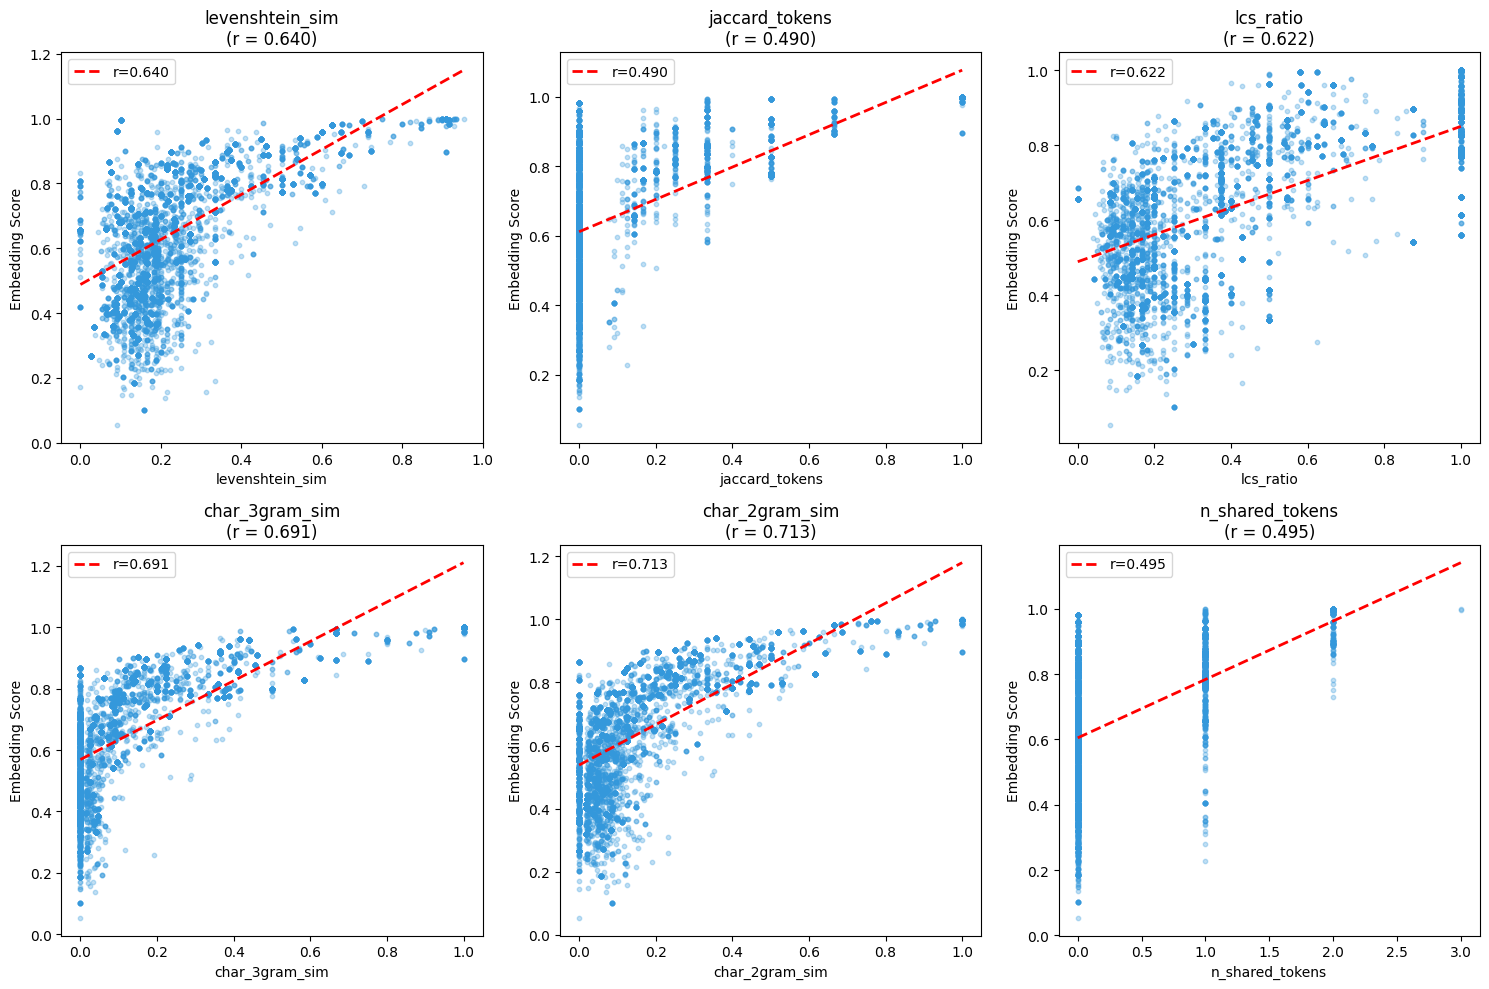


CASOS CON ALTA SIMILITUD LÉXICA (posible sesgo)

Casos con tokens compartidos: 2460 (24.6%)

Score medio CON tokens compartidos:    0.805
Score medio SIN tokens compartidos:    0.605
Diferencia: 0.200

T-test: t=53.461, p=0.000000
⚠️ Diferencia estadísticamente significativa - POSIBLE SESGO LÉXICO

📋 TOP 20 MATCHES CON MAYOR SIMILITUD LÉXICA:
----------------------------------------------------------------------------------------------------

Ingrediente: 'tomato puree'
  Match:         'Tomato puree'
  Tokens compart: ['puree', 'tomato']
  Jaccard:       1.000
  Embed Score:   0.984
  Confianza:     HIGH

Ingrediente: 'wheat bran'
  Match:         'Wheat bran'
  Tokens compart: ['wheat', 'bran']
  Jaccard:       1.000
  Embed Score:   0.997
  Confianza:     HIGH

Ingrediente: 'milk powder'
  Match:         'Milk powder'
  Tokens compart: ['powder', 'milk']
  Jaccard:       1.000
  Embed Score:   0.999
  Confianza:     HIGH

Ingrediente: 'barley flour'
  Match:         'Barley flour'


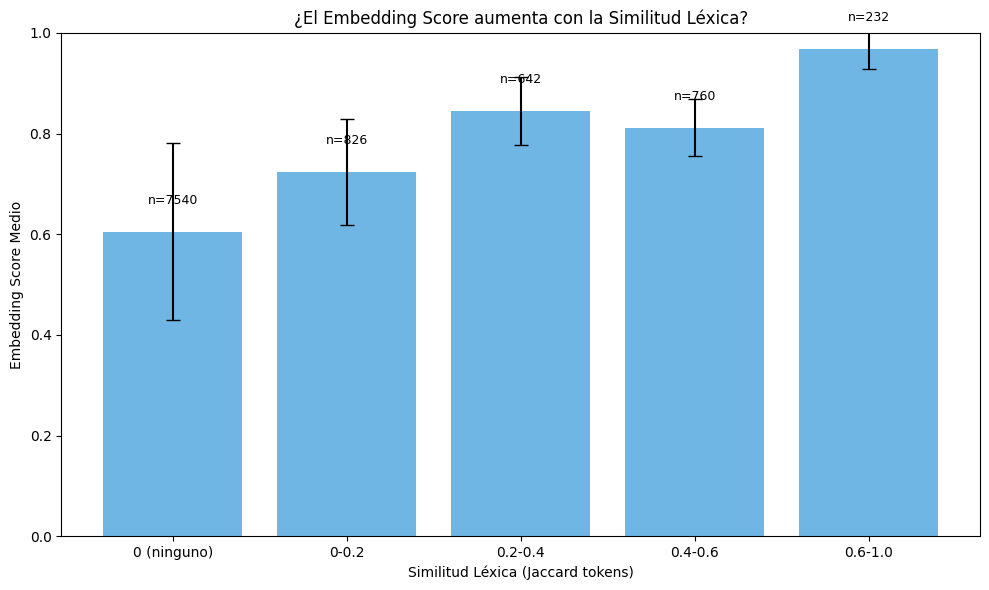


RESUMEN: ANÁLISIS DE SESGOS LÉXICOS Y FONÉTICOS

📊 CORRELACIONES LÉXICAS vs EMBEDDING SCORE:
   Correlación más alta: char_2gram_sim (r = 0.713)
   
   ⚠️ SESGO DETECTADO

📊 IMPACTO DE TOKENS COMPARTIDOS:
   Score medio CON tokens compartidos:  0.805
   Score medio SIN tokens compartidos:  0.605
   Diferencia: +0.200
   
   ⚠️ SESGO DETECTADO

📊 MATCHES POR SUBSTRING:
   Ingrediente contenido en match: 1895 (18.9%)
   Match contenido en ingrediente: 188 (1.9%)

📊 RECOMENDACIONES:

   🔴 Alta correlación léxica detectada. Considera:
      - Revisar manualmente matches con alta similitud léxica
      - Añadir regularización o penalización por similitud superficial
      - Usar un modelo de embeddings más robusto

✓ Exportado: lexical_bias_analysis.csv
✓ Exportado: suspicious_lexical_matches.csv


In [80]:
# =============================================================================
# ANÁLISIS DE SESGOS LÉXICOS Y FONÉTICOS EN EL MATCHING
# =============================================================================
# Objetivo: Detectar si el modelo está haciendo matching basado en similitud
# superficial (caracteres, tokens compartidos, prefijos) en lugar de semántica.

# %% [markdown]
# ## 14. Análisis de Sesgos Léxicos y Fonéticos

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from typing import List, Tuple
import warnings
warnings.filterwarnings('ignore')

# Opcional: para similitud fonética
try:
    import jellyfish
    HAS_JELLYFISH = True
except ImportError:
    HAS_JELLYFISH = False
    print("⚠️ jellyfish no instalado. Instalar con: pip install jellyfish")
    print("   Análisis fonético limitado.")

# %% [markdown]
# ### 14.1 Métricas de Similitud Léxica

# %%
def levenshtein_distance(s1: str, s2: str) -> int:
    """Distancia de edición entre dos strings."""
    if len(s1) < len(s2):
        return levenshtein_distance(s2, s1)
    if len(s2) == 0:
        return len(s1)

    previous_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = previous_row[j + 1] + 1
            deletions = current_row[j] + 1
            substitutions = previous_row[j] + (c1 != c2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row

    return previous_row[-1]

def levenshtein_similarity(s1: str, s2: str) -> float:
    """Similitud normalizada basada en Levenshtein (0-1)."""
    if not s1 or not s2:
        return 0.0
    max_len = max(len(s1), len(s2))
    if max_len == 0:
        return 1.0
    return 1 - (levenshtein_distance(s1, s2) / max_len)

def jaccard_tokens(s1: str, s2: str) -> float:
    """Similitud Jaccard basada en tokens (palabras)."""
    tokens1 = set(s1.lower().split())
    tokens2 = set(s2.lower().split())
    if not tokens1 or not tokens2:
        return 0.0
    intersection = tokens1 & tokens2
    union = tokens1 | tokens2
    return len(intersection) / len(union) if union else 0.0

def shared_tokens(s1: str, s2: str) -> List[str]:
    """Retorna tokens compartidos entre dos strings."""
    tokens1 = set(s1.lower().split())
    tokens2 = set(s2.lower().split())
    return list(tokens1 & tokens2)

def longest_common_substring(s1: str, s2: str) -> str:
    """Encuentra el substring común más largo."""
    s1, s2 = s1.lower(), s2.lower()
    m, n = len(s1), len(s2)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    longest, end_pos = 0, 0

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
                if dp[i][j] > longest:
                    longest = dp[i][j]
                    end_pos = i

    return s1[end_pos - longest:end_pos]

def lcs_ratio(s1: str, s2: str) -> float:
    """Ratio del substring común más largo respecto al string más corto."""
    lcs = longest_common_substring(s1, s2)
    min_len = min(len(s1), len(s2))
    return len(lcs) / min_len if min_len > 0 else 0.0

def shared_prefix_length(s1: str, s2: str) -> int:
    """Longitud del prefijo compartido."""
    s1, s2 = s1.lower(), s2.lower()
    i = 0
    while i < len(s1) and i < len(s2) and s1[i] == s2[i]:
        i += 1
    return i

def shared_suffix_length(s1: str, s2: str) -> int:
    """Longitud del sufijo compartido."""
    s1, s2 = s1.lower(), s2.lower()
    i = 0
    while i < len(s1) and i < len(s2) and s1[-(i+1)] == s2[-(i+1)]:
        i += 1
    return i

def char_ngram_similarity(s1: str, s2: str, n: int = 3) -> float:
    """Similitud basada en n-gramas de caracteres."""
    s1, s2 = s1.lower(), s2.lower()

    def get_ngrams(s, n):
        return set(s[i:i+n] for i in range(len(s) - n + 1))

    if len(s1) < n or len(s2) < n:
        return 0.0

    ngrams1 = get_ngrams(s1, n)
    ngrams2 = get_ngrams(s2, n)

    intersection = ngrams1 & ngrams2
    union = ngrams1 | ngrams2

    return len(intersection) / len(union) if union else 0.0

# %%
def compute_lexical_metrics(df: pd.DataFrame,
                            ingredient_col: str = 'ingredient',
                            match_col: str = 'final_name') -> pd.DataFrame:
    """
    Calcula todas las métricas de similitud léxica para cada par ingrediente-match.
    """
    print("Calculando métricas léxicas...")

    metrics = []

    for idx, row in df.iterrows():
        ingredient = str(row[ingredient_col]).strip()
        match = str(row[match_col]).strip()

        metric = {
            'ingredient': ingredient,
            'match': match,
            'embedding_score': row.get('final_score', 0),
            'confidence': row.get('confidence', 'UNKNOWN'),

            # Métricas léxicas
            'levenshtein_sim': levenshtein_similarity(ingredient, match),
            'jaccard_tokens': jaccard_tokens(ingredient, match),
            'lcs_ratio': lcs_ratio(ingredient, match),
            'shared_prefix_len': shared_prefix_length(ingredient, match),
            'shared_suffix_len': shared_suffix_length(ingredient, match),
            'char_3gram_sim': char_ngram_similarity(ingredient, match, 3),
            'char_2gram_sim': char_ngram_similarity(ingredient, match, 2),

            # Características adicionales
            'ingredient_len': len(ingredient),
            'match_len': len(match),
            'len_ratio': len(ingredient) / len(match) if len(match) > 0 else 0,
            'shared_tokens': shared_tokens(ingredient, match),
            'n_shared_tokens': len(shared_tokens(ingredient, match)),

            # Tokens exactos
            'exact_token_match': any(t in match.lower().split() for t in ingredient.lower().split()),
            'ingredient_in_match': ingredient.lower() in match.lower(),
            'match_in_ingredient': match.lower() in ingredient.lower(),
        }

        # Métricas fonéticas (si jellyfish está disponible)
        if HAS_JELLYFISH:
            try:
                metric['soundex_match'] = jellyfish.soundex(ingredient) == jellyfish.soundex(match)
                metric['metaphone_sim'] = jellyfish.jaro_winkler_similarity(
                    jellyfish.metaphone(ingredient),
                    jellyfish.metaphone(match)
                )
            except:
                metric['soundex_match'] = False
                metric['metaphone_sim'] = 0.0

        metrics.append(metric)

    print(f"✓ Calculadas métricas para {len(metrics)} pares")
    return pd.DataFrame(metrics)

# %% [markdown]
# ### 14.2 Ejecutar Análisis

# %%
# Calcular métricas léxicas para todo el dataset (o una muestra)
# Para datasets grandes, usar una muestra
sample_size = min(10000, len(stratified_df))
sample_df = stratified_df.sample(n=sample_size, random_state=42)

lexical_df = compute_lexical_metrics(sample_df)

# %% [markdown]
# ### 14.3 Correlación entre Similitud Léxica y Score de Embedding

# %%
print("=" * 80)
print("CORRELACIÓN: SIMILITUD LÉXICA vs SCORE DE EMBEDDING")
print("=" * 80)

# Columnas de métricas léxicas
lexical_cols = [
    'levenshtein_sim', 'jaccard_tokens', 'lcs_ratio',
    'char_3gram_sim', 'char_2gram_sim', 'n_shared_tokens'
]

print(f"\n{'Métrica Léxica':<25} {'Correlación':>12} {'Interpretación':<30}")
print("-" * 70)

correlations = {}
for col in lexical_cols:
    corr = lexical_df['embedding_score'].corr(lexical_df[col])
    correlations[col] = corr

    # Interpretación
    if abs(corr) > 0.5:
        interpretation = "⚠️ SESGO ALTO - Revisar"
    elif abs(corr) > 0.3:
        interpretation = "🟡 Sesgo moderado"
    elif abs(corr) > 0.1:
        interpretation = "🟢 Sesgo bajo"
    else:
        interpretation = "✅ Sin sesgo detectado"

    print(f"{col:<25} {corr:>12.4f} {interpretation:<30}")

# %%
# Visualización de correlaciones
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(lexical_cols):
    ax = axes[i]

    # Scatter plot con línea de regresión
    ax.scatter(lexical_df[col], lexical_df['embedding_score'],
               alpha=0.3, s=10, c='#3498db')

    # Línea de regresión
    z = np.polyfit(lexical_df[col], lexical_df['embedding_score'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(lexical_df[col].min(), lexical_df[col].max(), 100)
    ax.plot(x_line, p(x_line), 'r--', linewidth=2, label=f'r={correlations[col]:.3f}')

    ax.set_xlabel(col)
    ax.set_ylabel('Embedding Score')
    ax.set_title(f'{col}\n(r = {correlations[col]:.3f})')
    ax.legend()

plt.tight_layout()
plt.savefig('lexical_bias_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

# %% [markdown]
# ### 14.4 Análisis de Casos con Alta Similitud Léxica

# %%
print("\n" + "=" * 80)
print("CASOS CON ALTA SIMILITUD LÉXICA (posible sesgo)")
print("=" * 80)

# Casos donde jaccard_tokens > 0 (comparten al menos un token)
shared_token_cases = lexical_df[lexical_df['jaccard_tokens'] > 0].copy()
print(f"\nCasos con tokens compartidos: {len(shared_token_cases)} ({len(shared_token_cases)/len(lexical_df)*100:.1f}%)")

# Distribución de scores para casos con vs sin tokens compartidos
with_shared = lexical_df[lexical_df['jaccard_tokens'] > 0]['embedding_score']
without_shared = lexical_df[lexical_df['jaccard_tokens'] == 0]['embedding_score']

print(f"\nScore medio CON tokens compartidos:    {with_shared.mean():.3f}")
print(f"Score medio SIN tokens compartidos:    {without_shared.mean():.3f}")
print(f"Diferencia: {with_shared.mean() - without_shared.mean():.3f}")

# Test estadístico
from scipy import stats
t_stat, p_value = stats.ttest_ind(with_shared, without_shared)
print(f"\nT-test: t={t_stat:.3f}, p={p_value:.6f}")
if p_value < 0.05:
    print("⚠️ Diferencia estadísticamente significativa - POSIBLE SESGO LÉXICO")
else:
    print("✅ Diferencia no significativa")

# %%
# Ejemplos de matches con alta similitud léxica
print("\n📋 TOP 20 MATCHES CON MAYOR SIMILITUD LÉXICA:")
print("-" * 100)

high_lexical = lexical_df.nlargest(20, 'jaccard_tokens')
for _, row in high_lexical.iterrows():
    print(f"\nIngrediente: '{row['ingredient']}'")
    print(f"  Match:         '{row['match']}'")
    print(f"  Tokens compart: {row['shared_tokens']}")
    print(f"  Jaccard:       {row['jaccard_tokens']:.3f}")
    print(f"  Embed Score:   {row['embedding_score']:.3f}")
    print(f"  Confianza:     {row['confidence']}")

# %% [markdown]
# ### 14.5 Análisis de Casos Sospechosos

# %%
print("\n" + "=" * 80)
print("CASOS SOSPECHOSOS: Alta similitud léxica pero baja semántica esperada")
print("=" * 80)

# Casos donde hay alta similitud léxica (>0.3) y alto embedding score (>0.7)
# pero el match parece incorrecto basándose en el substring común
suspicious = lexical_df[
    (lexical_df['lcs_ratio'] > 0.4) &
    (lexical_df['embedding_score'] > 0.7)
].copy()

print(f"\nCasos con LCS ratio > 0.4 Y embedding score > 0.7: {len(suspicious)}")
print("\nEjemplos (verificar manualmente si el match es semánticamente correcto):")
print("-" * 100)

for _, row in suspicious.head(15).iterrows():
    lcs = longest_common_substring(row['ingredient'], row['match'])
    print(f"\nIngrediente: '{row['ingredient']}'")
    print(f"  Match:      '{row['match']}'")
    print(f"  Substring común: '{lcs}' (ratio: {row['lcs_ratio']:.2f})")
    print(f"  Embed Score: {row['embedding_score']:.3f}")

# %% [markdown]
# ### 14.6 Análisis de Prefijos/Sufijos

# %%
print("\n" + "=" * 80)
print("ANÁLISIS DE PREFIJOS Y SUFIJOS COMPARTIDOS")
print("=" * 80)

# Casos con prefijo compartido largo (>3 caracteres)
long_prefix = lexical_df[lexical_df['shared_prefix_len'] >= 4].copy()
print(f"\nCasos con prefijo compartido ≥4 caracteres: {len(long_prefix)} ({len(long_prefix)/len(lexical_df)*100:.1f}%)")
print(f"Score medio: {long_prefix['embedding_score'].mean():.3f}")

# Casos con sufijo compartido largo (>3 caracteres)
long_suffix = lexical_df[lexical_df['shared_suffix_len'] >= 4].copy()
print(f"\nCasos con sufijo compartido ≥4 caracteres: {len(long_suffix)} ({len(long_suffix)/len(lexical_df)*100:.1f}%)")
print(f"Score medio: {long_suffix['embedding_score'].mean():.3f}")

# Ejemplos de prefijos compartidos
print("\n📋 EJEMPLOS DE PREFIJOS COMPARTIDOS LARGOS:")
for _, row in long_prefix.head(10).iterrows():
    prefix = row['ingredient'][:row['shared_prefix_len']]
    print(f"  '{row['ingredient'][:30]}' → '{row['match'][:30]}' | Prefijo: '{prefix}'")

# %% [markdown]
# ### 14.7 Detección de Matches por Substring Exacto

# %%
print("\n" + "=" * 80)
print("MATCHES POR SUBSTRING EXACTO (ingrediente contenido en match o viceversa)")
print("=" * 80)

# Ingrediente contenido en match
ing_in_match = lexical_df[lexical_df['ingredient_in_match']].copy()
print(f"\nIngrediente contenido en match: {len(ing_in_match)} ({len(ing_in_match)/len(lexical_df)*100:.1f}%)")
print(f"Score medio: {ing_in_match['embedding_score'].mean():.3f}")

print("\nEjemplos:")
for _, row in ing_in_match.head(10).iterrows():
    print(f"  '{row['ingredient']}' → '{row['match']}'")

# Match contenido en ingrediente
match_in_ing = lexical_df[lexical_df['match_in_ingredient']].copy()
print(f"\nMatch contenido en ingrediente: {len(match_in_ing)} ({len(match_in_ing)/len(lexical_df)*100:.1f}%)")

# %% [markdown]
# ### 14.8 Comparación: Scores por Nivel de Similitud Léxica

# %%
# Crear bins de similitud léxica
lexical_df['lexical_bin'] = pd.cut(
    lexical_df['jaccard_tokens'],
    bins=[-0.01, 0, 0.2, 0.4, 0.6, 1.0],
    labels=['0 (ninguno)', '0-0.2', '0.2-0.4', '0.4-0.6', '0.6-1.0']
)

# Estadísticas por bin
print("\n" + "=" * 80)
print("SCORE DE EMBEDDING POR NIVEL DE SIMILITUD LÉXICA (Jaccard tokens)")
print("=" * 80)

bin_stats = lexical_df.groupby('lexical_bin').agg({
    'embedding_score': ['mean', 'std', 'count'],
    'confidence': lambda x: (x == 'HIGH').mean() * 100
}).round(3)

print(bin_stats)

# Visualización
fig, ax = plt.subplots(figsize=(10, 6))

bin_order = ['0 (ninguno)', '0-0.2', '0.2-0.4', '0.4-0.6', '0.6-1.0']
means = [lexical_df[lexical_df['lexical_bin'] == b]['embedding_score'].mean() for b in bin_order]
stds = [lexical_df[lexical_df['lexical_bin'] == b]['embedding_score'].std() for b in bin_order]
counts = [len(lexical_df[lexical_df['lexical_bin'] == b]) for b in bin_order]

bars = ax.bar(bin_order, means, yerr=stds, capsize=5, color='#3498db', alpha=0.7)
ax.set_xlabel('Similitud Léxica (Jaccard tokens)')
ax.set_ylabel('Embedding Score Medio')
ax.set_title('¿El Embedding Score aumenta con la Similitud Léxica?')
ax.set_ylim(0, 1)

# Añadir conteos
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'n={count}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('lexical_vs_embedding_score.png', dpi=150, bbox_inches='tight')
plt.show()

# %% [markdown]
# ### 14.9 Resumen del Análisis de Sesgos

# %%
print("\n" + "=" * 80)
print("RESUMEN: ANÁLISIS DE SESGOS LÉXICOS Y FONÉTICOS")
print("=" * 80)

# Calcular indicadores de sesgo
max_corr = max(abs(c) for c in correlations.values())
max_corr_metric = max(correlations, key=lambda k: abs(correlations[k]))

score_diff = with_shared.mean() - without_shared.mean()

print(f"""
📊 CORRELACIONES LÉXICAS vs EMBEDDING SCORE:
   Correlación más alta: {max_corr_metric} (r = {correlations[max_corr_metric]:.3f})

   {'⚠️ SESGO DETECTADO' if max_corr > 0.3 else '✅ Sin sesgo significativo'}

📊 IMPACTO DE TOKENS COMPARTIDOS:
   Score medio CON tokens compartidos:  {with_shared.mean():.3f}
   Score medio SIN tokens compartidos:  {without_shared.mean():.3f}
   Diferencia: {score_diff:+.3f}

   {'⚠️ SESGO DETECTADO' if abs(score_diff) > 0.05 and p_value < 0.05 else '✅ Sin sesgo significativo'}

📊 MATCHES POR SUBSTRING:
   Ingrediente contenido en match: {len(ing_in_match)} ({len(ing_in_match)/len(lexical_df)*100:.1f}%)
   Match contenido en ingrediente: {len(match_in_ing)} ({len(match_in_ing)/len(lexical_df)*100:.1f}%)

📊 RECOMENDACIONES:
""")

if max_corr > 0.3:
    print("   🔴 Alta correlación léxica detectada. Considera:")
    print("      - Revisar manualmente matches con alta similitud léxica")
    print("      - Añadir regularización o penalización por similitud superficial")
    print("      - Usar un modelo de embeddings más robusto")
elif max_corr > 0.15:
    print("   🟡 Correlación léxica moderada. Considera:")
    print("      - Verificar casos con tokens exactos compartidos")
    print("      - Evaluar si los matches son semánticamente correctos")
else:
    print("   🟢 El matching parece basarse principalmente en semántica, no en léxico")

# %% [markdown]
# ### 14.10 Exportar Resultados

# %%
# Guardar análisis léxico
lexical_df.to_csv('lexical_bias_analysis.csv', index=False)
print("\n✓ Exportado: lexical_bias_analysis.csv")

# Guardar casos sospechosos para revisión manual
suspicious.to_csv('suspicious_lexical_matches.csv', index=False)
print("✓ Exportado: suspicious_lexical_matches.csv")

## ALLERGENS MATCHING



In [8]:
# 1. Ver todas las categorías de nivel 2 (principales)
print("=== NIVEL 2: Categorías principales ===")
level_2 = foodex2_df[foodex2_df['reportHierarchyLevel'] == 2][['termCode', 'termExtendedName']]
for _, row in level_2.iterrows():
    print(f"{row['termCode']}: {row['termExtendedName']}")

=== NIVEL 2: Categorías principales ===
A000J: Grains and grain-based products
A010R: Sugar plants
A015E: Oilseeds and oilfruits
A031E: Eggs and egg products
A03JZ: Hot drinks and similar (coffee, cocoa, tea and herbal infusions)
A03LZ: Alcoholic beverages
A03PV: Food products for young population
A03RR: Food for particular diets
A03TD: Meat and dairy imitates
A03VA: Composite dishes
A042N: Seasoning, sauces and condiments
A04PE: Confectionery including chocolate
A07XJ: Garden vegetables and primary derivatives thereof
A0BA7: Food simulants
A0BXX: Isolated purified ingredients (including mineral or synthetic)
A0BXZ: Milk and milk products (dairy)
A0C5Y: Environment
A0C5Z: Food contact materials
A0C60: Non-food animal-related matrices
A0EZG: Legume seeds and primary derivatives thereof
A0EZH: Nuts and primary derivatives thereof
A0EZM: Herbs, spices and similar
A0EZN: Fruit and primary derivatives thereof
A0EZP: Fruit/vegetables/plant drinks, spreads and related products
A0EZQ: Seafood 

In [9]:
# 2. Ver categorías de nivel 3 relevantes para alérgenos
print("\n=== NIVEL 3: Sub-categorías ===")
level_3 = foodex2_df[foodex2_df['reportHierarchyLevel'] == 3][['termCode', 'termExtendedName', 'reportHierarchyCode']]
print(f"Total términos nivel 3: {len(level_3)}")
print(level_3.to_string())


=== NIVEL 3: Sub-categorías ===
Total términos nivel 3: 157
     termCode                                                                                    termExtendedName reportHierarchyCode
308     A00FL                                                                                  Flowering brassica     Z0001.0002.0003
339     A00GX                                                                                     Bulb vegetables     Z0001.0002.0006
354     A00HN                                                                                 Fruiting vegetables     Z0001.0002.0008
400     A00KR                                                                                    Leafy vegetables     Z0001.0002.0001
473     A00PB                                                                                    Legumes with pod     Z0001.0002.0007
499     A00QF                                           Root and tuber vegetables (excluding starchy- and sugar-)     Z0001.0002.0009
5

In [10]:
# 3. Buscar términos que contengan palabras clave de alérgenos
allergen_keywords = [
    'milk', 'dairy', 'cheese', 'cream', 'butter', 'whey', 'lactose', 'casein',
    'egg', 'albumin', 'ovum',
    'wheat', 'gluten', 'barley', 'rye', 'oat', 'spelt',
    'soy', 'soya', 'lecithin',
    'peanut', 'groundnut',
    'almond', 'hazelnut', 'walnut', 'cashew', 'pistachio', 'pecan', 'macadamia', 'nut',
    'fish', 'salmon', 'tuna', 'anchov', 'cod',
    'crustacean', 'shrimp', 'prawn', 'crab', 'lobster',
    'mollusc', 'mussel', 'clam', 'oyster', 'squid', 'octopus',
    'celery', 'celeriac',
    'mustard',
    'sesame', 'tahini',
    'sulphite', 'sulfite', 'sulphur', 'sulfur',
    'lupin', 'lupine'
]

print("\n=== TÉRMINOS RELACIONADOS CON ALÉRGENOS ===")
for keyword in allergen_keywords:
    matches = foodex2_df[foodex2_df['termExtendedName'].str.lower().str.contains(keyword, na=False)]
    if len(matches) > 0:
        print(f"\n--- '{keyword}' ({len(matches)} matches) ---")
        for _, row in matches.iterrows():
            print(f"  {row['termCode']} (L{row['reportHierarchyLevel']}): {row['termExtendedName']}")


=== TÉRMINOS RELACIONADOS CON ALÉRGENOS ===

--- 'milk' (92 matches) ---
  A00TH (L5): Saffron milk cap
  A01BK (L5): Coconut milk (cocos nucifera) liquid
  A028M (L6): Milkfish
  A02HH (L4): Ovine milk
  A02LT (L3): Milk
  A02LV (L5): Cow milk
  A02LX (L6): Cow milk, natural high fat
  A02LY (L6): Cow milk, whole
  A02LZ (L6): Cow milk, semi skimmed (half fat)
  A02MA (L6): Cow milk, skimmed (low fat)
  A02MB (L4): Goat milk
  A02MC (L5): Sheep milk
  A02MD (L5): Water buffalo milk
  A02ME (L5): Bactrian camel milk
  A02MF (L5): Horse milk
  A02MG (L5): Ass milk
  A02MH (L5): Milk from other milk producer animals
  A02MJ (L5): Human milk
  A02MP (L3): Flavoured milks
  A02MV (L3): Buttermilk
  A02MX (L4): Traditional buttermilk (churning)
  A02MY (L4): Cultured buttermilk
  A02NF (L5): Yoghurt, cow milk
  A02NG (L6): Yoghurt, cow milk, plain
  A02NH (L6): Yoghurt, cow milk, flavoured
  A02NJ (L5): Yoghurt, sheep milk
  A02NK (L6): Yoghurt, sheep milk, plain
  A02NL (L6): Yoghurt, she